<a href="https://colab.research.google.com/github/Adi21032004/Walmart_Sales_Forecasting/blob/main/Walmart_store_sales_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing files
from google.colab import files
doc = files.upload()

Saving stores.csv to stores.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df['IsHoliday'] = df['IsHoliday'].map(lambda x: 1 if x==True else 0)
df.head(5)
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes
# df.isna().sum()
df.shape
# df.nunique()
# df['Dept'].value_counts()
# df.columns

(421570, 5)

In [4]:
stores = pd.read_csv('stores.csv')
stores.head(5)
# stores.columns
# stores.nunique()
# stores.shape

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
from google.colab import files
f = files.upload()

Saving features.csv to features.csv


In [6]:
feature = pd.read_csv('features.csv')
# feature.head(5)
# feature.nunique()
# feature['Unemployment'].value_counts()
# feature.isna().sum()
# feature.dtypes

In [7]:
store1 = df.query('Store == 1').copy()
dept1 = store1.query('Dept == 1').copy()
dept1 = dept1.drop(columns=['Store','IsHoliday'])
# dept1

In [8]:
!pip install utilsforecast
# from utilsforcast.plotting import plot_series


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.1 MB/s eta 0:00:00


In [9]:
from utilsforecast.plotting import plot_series

dept1 = dept1.rename(columns={'Date':'ds','Weekly_Sales':'y',"Dept": "unique_id"})
# dept1.head(5)
dept1['ds'] = pd.to_datetime(dept1['ds'])
# plot_series(df=dept1,ids=[1],palette='viridis')

In [10]:
all_dept = store1
all_dept
all_dept = all_dept.drop(columns=['Store','IsHoliday'])
all_dept = all_dept.rename(columns={'Date':'ds','Weekly_Sales':'y',"Dept": "unique_id"})
all_dept['ds'] = pd.to_datetime(all_dept['ds'])
plot_series(df=all_dept,ids=[1,2,3,4,5,6],palette='viridis')

def plot_dept(df,store_id,dept_ids):
    store1 = df.query(f'Store == {store_id}').copy()
    store1 = store1.drop(columns=['Store','IsHoliday'])
    store1 = store1.rename(columns={'Date':'ds','Weekly_Sales':'y',"Dept": "unique_id"})
    store1['ds'] = pd.to_datetime(store1['ds'])
    return plot_series(df=store1,ids=dept_ids,palette='viridis')


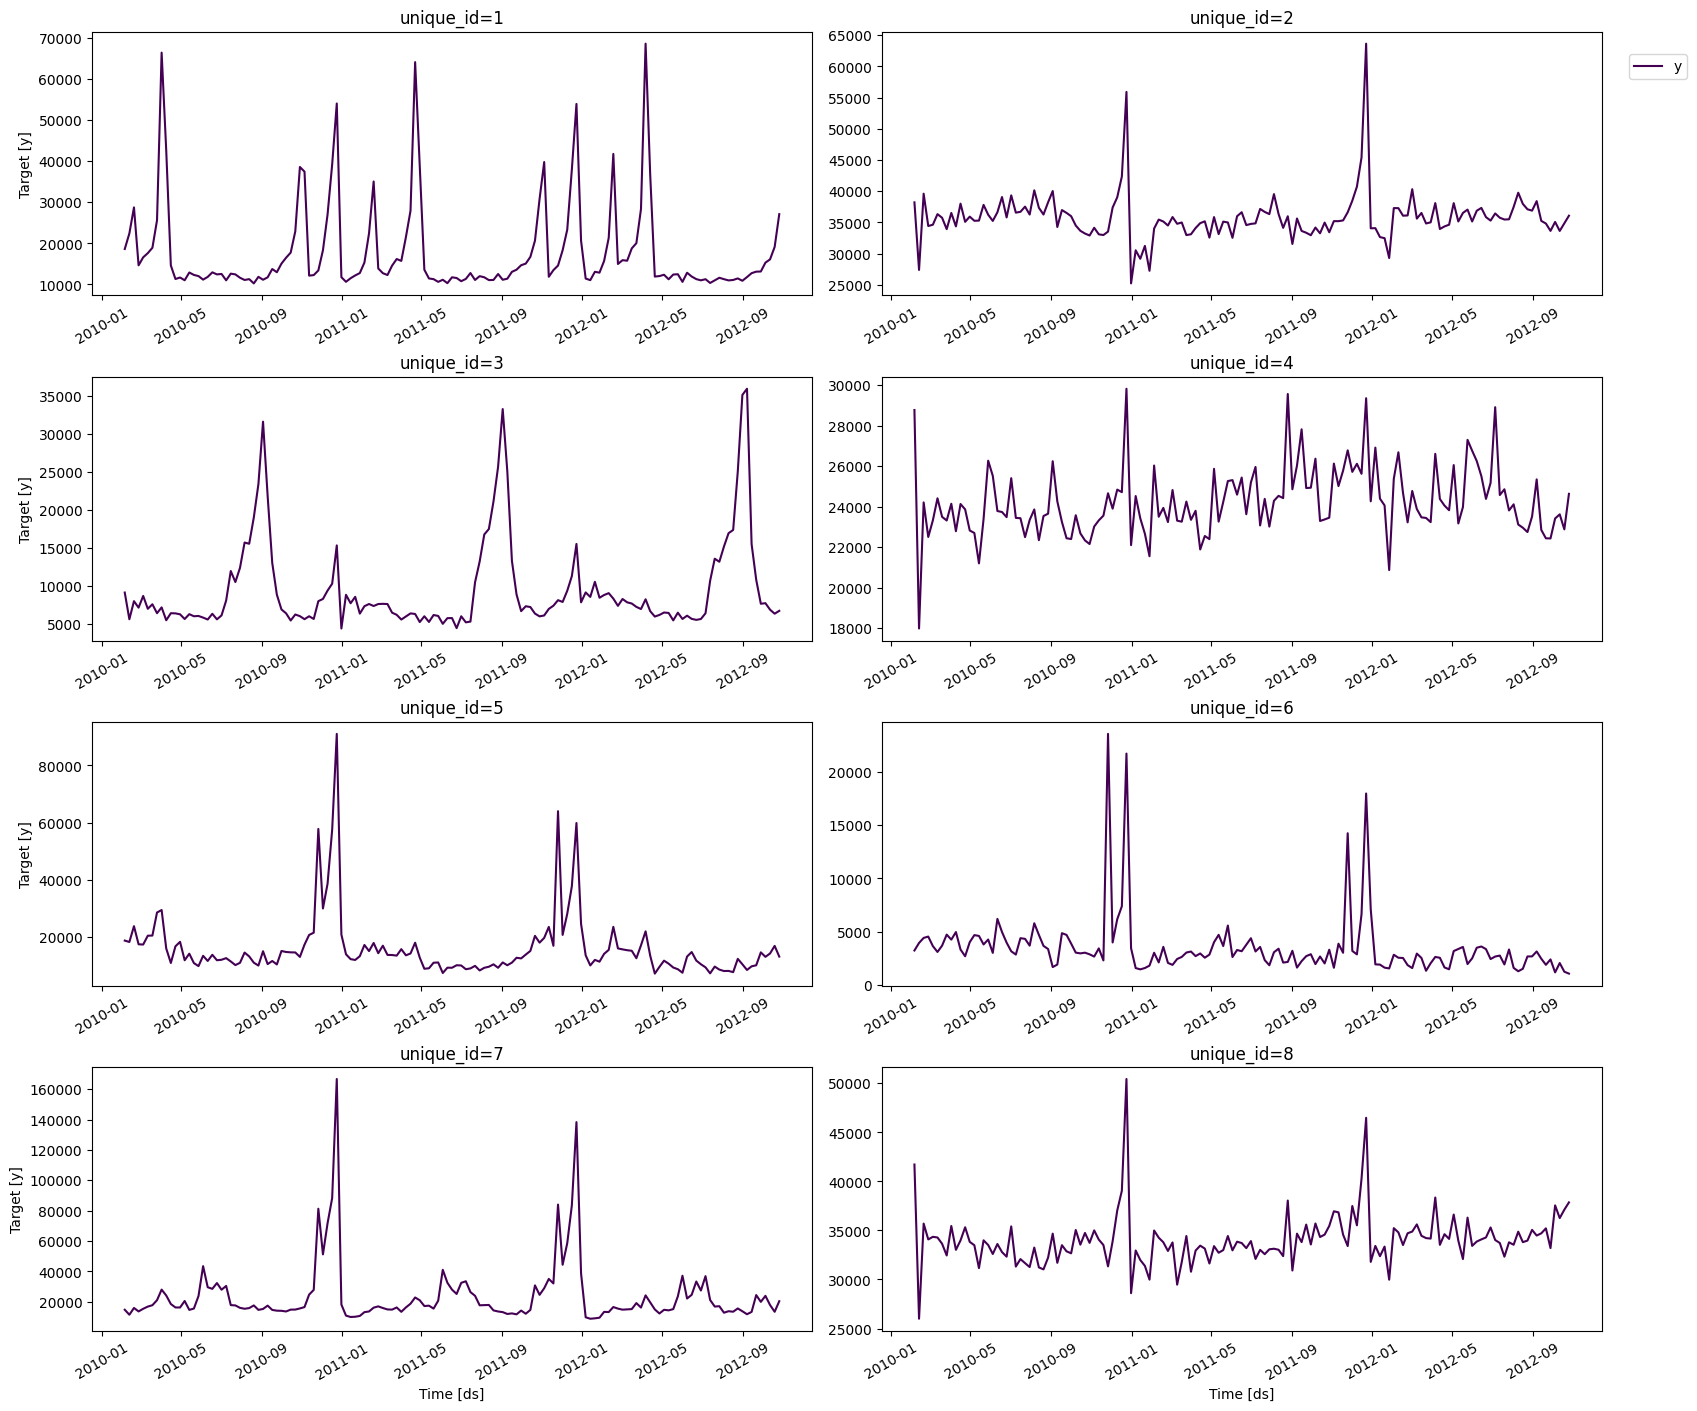

In [11]:
plot_dept(df,45,[1,2,3,4,5,6,7,8])

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(16, 7))

# sns.boxplot(
#     data=df,
#     x='Store',
#     y='Weekly_Sales'
# )

# plt.title('Weekly Sales Distribution by store')
# plt.xlabel('Store')
# plt.ylabel('Weekly Sales')

# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(16, 7))

# sns.boxplot(
#     data=df,
#     x='Dept',
#     y='Weekly_Sales'
# )

# plt.title('Weekly Sales Distribution by Department')
# plt.xlabel('Department')
# plt.ylabel('Weekly Sales')

# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

In [ ]:
# store_number = 1

# store_data = df[df['Store'] == store_number]

# plt.figure(figsize=(16, 7))

# sns.boxplot(
#     data=store_data,
#     x='Dept',
#     y='Weekly_Sales'
# )

# plt.title(f'Weekly Sales Distribution by Department — Store {store_number}')
# plt.xlabel('Department')
# plt.ylabel('Weekly Sales')

# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

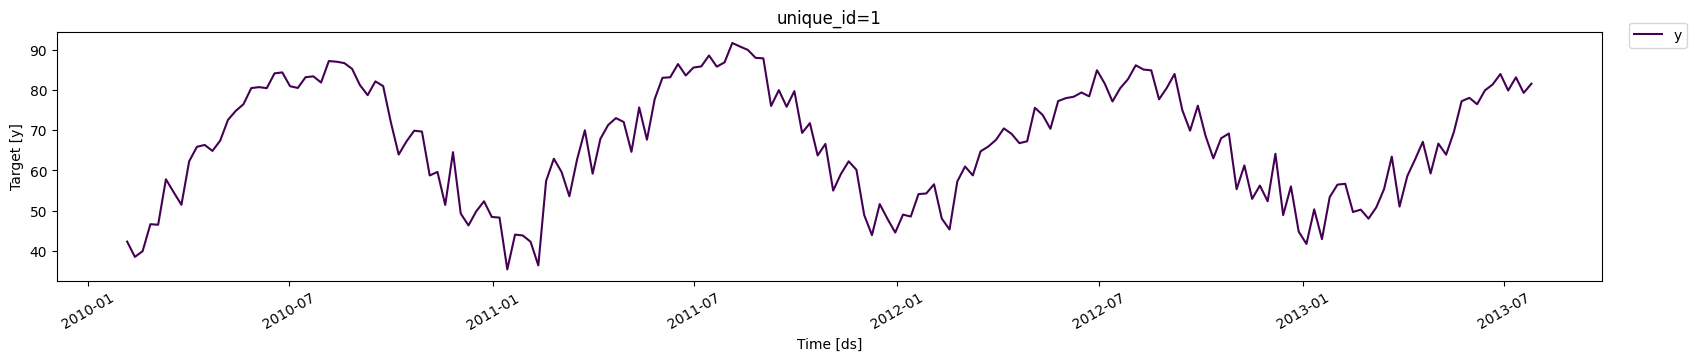

In [12]:
feature.head(5)
temp_curve = feature.drop(columns=['Fuel_Price','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment']).copy()
temp_curve = temp_curve.rename(columns={'Date':'ds','Temperature':'y','Store':'unique_id'})
temp_curve['ds'] = pd.to_datetime(temp_curve['ds'])
plot_series(df=temp_curve, ids=[1], palette='viridis')


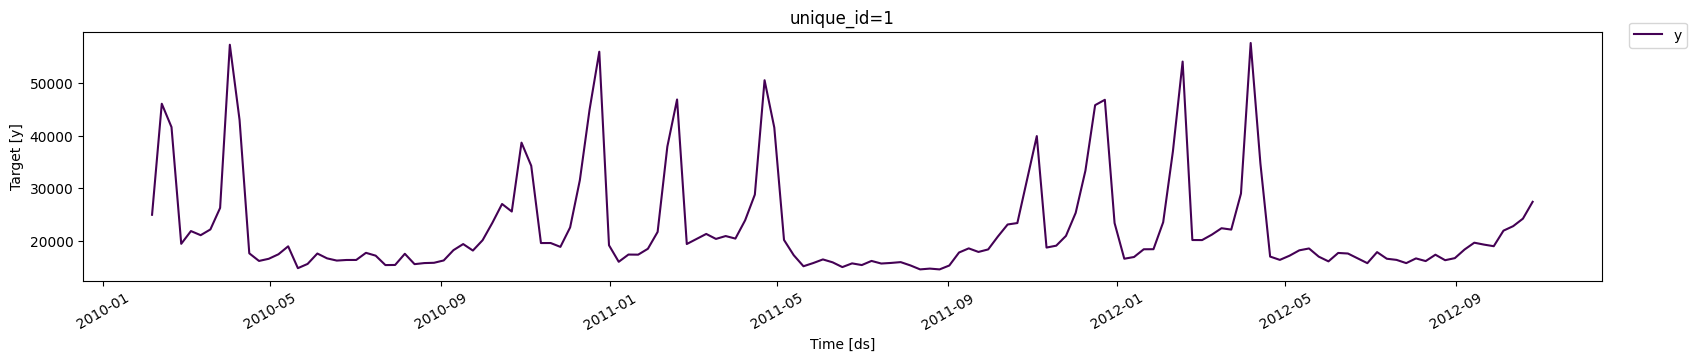

In [13]:
plot_dept(df,1,[1])

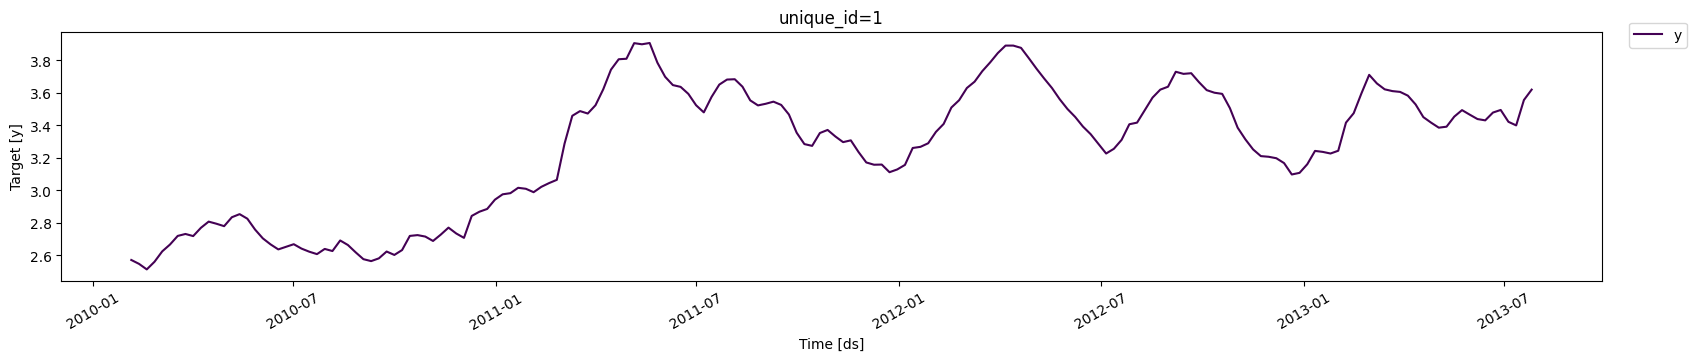

In [14]:
feature.head(5)
temp_curve = feature.drop(columns=['Temperature','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment']).copy()
temp_curve = temp_curve.rename(columns={'Date':'ds','Fuel_Price':'y','Store':'unique_id'})
temp_curve['ds'] = pd.to_datetime(temp_curve['ds'])
plot_series(df=temp_curve, ids=[1], palette='viridis')


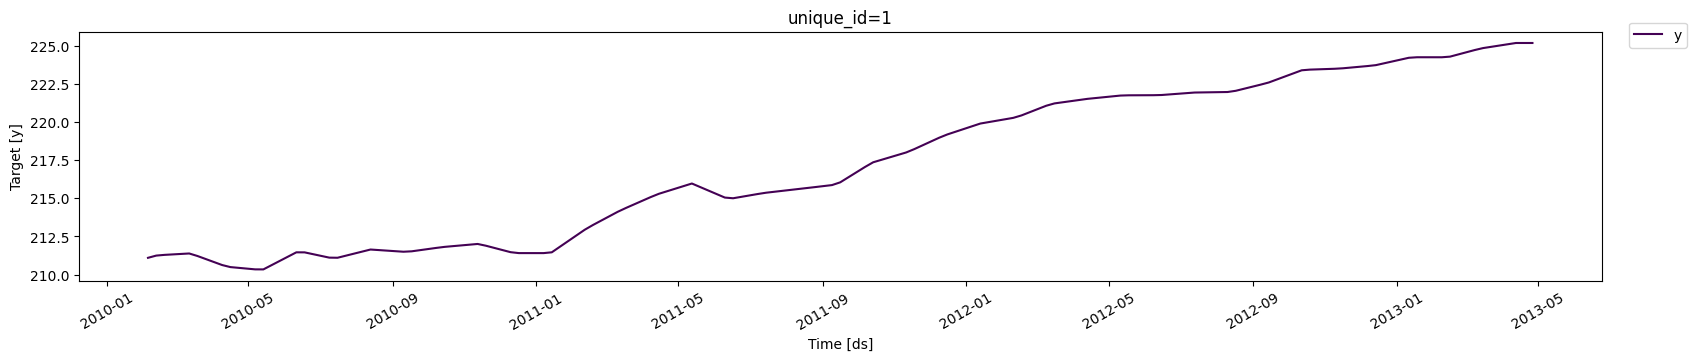

In [15]:
temp_curve = feature.drop(columns=['Temperature','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','Fuel_Price','Unemployment']).copy()
temp_curve = temp_curve.rename(columns={'Date':'ds','CPI':'y','Store':'unique_id'})
temp_curve['ds'] = pd.to_datetime(temp_curve['ds'])
plot_series(df=temp_curve, ids=[1], palette='viridis')

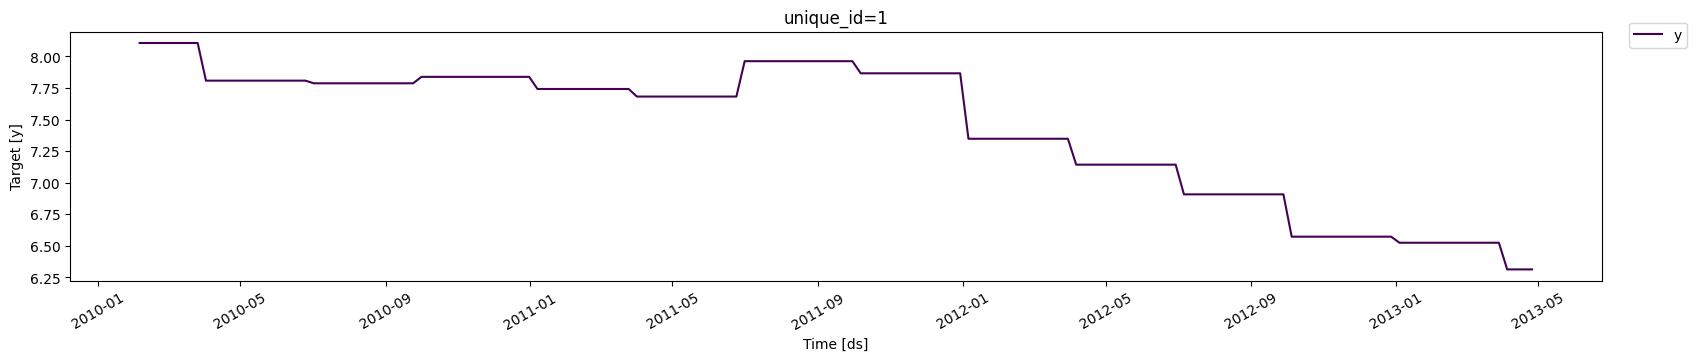

In [16]:
temp_curve = feature.drop(columns=['Temperature','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','Fuel_Price','CPI']).copy()
temp_curve = temp_curve.rename(columns={'Date':'ds','Unemployment':'y','Store':'unique_id'})
temp_curve['ds'] = pd.to_datetime(temp_curve['ds'])
plot_series(df=temp_curve, ids=[1], palette='viridis')

In [17]:
from sklearn.model_selection import train_test_split

n_df = df.query('Store == 1 and Dept == 1').copy()
n_df = n_df.drop(columns=['Store','IsHoliday'])

train_set = n_df.iloc[:-10].copy()
test_set = n_df.iloc[-10:]

train_set  = train_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

train_set['Date'] = pd.to_datetime(train_set['Date'])
test_set['Date'] = pd.to_datetime(test_set['Date'])

train_set = train_set.rename(columns={'Date':'ds','Weekly_Sales':'y','Dept':'unique_id'})
test_set = test_set.rename(columns={'Date':'ds','Weekly_Sales':'y','Dept':'unique_id'})

train_set['unique_id']=1
test_set['unique_id']=1

# x_train = train_set.drop(columns=['Weekly_Sales'])
# y_train = train_set['Weekly_Sales']

# x_test = test_set.drop(columns=['Weekly_Sales'])
# y_test = test_set['Weekly_Sales']

# y_train = y_train.reset_index(drop=True)
# x_train = x_train.reset_index(drop=True)
# x_train['Date'] = pd.to_datetime(x_train['Date'])
# x_train = x_train.sort_values
# print(train_set.shape)
# x_train.dtypes
# y_train.head(5)

In [18]:
!pip install statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.5 MB/s eta 0:00:00


In [19]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
size=52 #repeating every year
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(size),
    SeasonalNaive(season_length=size)
]

forecast_model = StatsForecast(models,freq='W-FRI')

forecast_model.fit(df=train_set)

StatsForecast(models=[Naive,HistoricAverage,WindowAverage,SeasonalNaive])

In [20]:
pred = forecast_model.predict(h=len(test_set))

In [21]:
pred

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,1,2012-08-24,17330.7,22662.075789,22890.514231,14537.37
1,1,2012-08-31,17330.7,22662.075789,22890.514231,15277.27
2,1,2012-09-07,17330.7,22662.075789,22890.514231,17746.68
3,1,2012-09-14,17330.7,22662.075789,22890.514231,18535.48
4,1,2012-09-21,17330.7,22662.075789,22890.514231,17859.30
5,1,2012-09-28,17330.7,22662.075789,22890.514231,18337.68
6,1,2012-10-05,17330.7,22662.075789,22890.514231,20797.58
7,1,2012-10-12,17330.7,22662.075789,22890.514231,23077.55
8,1,2012-10-19,17330.7,22662.075789,22890.514231,23351.80
9,1,2012-10-26,17330.7,22662.075789,22890.514231,31579.90


In [22]:
# test_set.head(5)
# train_set.tail(7)
eval_df = pd.merge(test_set,pred,on=['unique_id','ds'],how='left')
eval_df

,unique_id,ds,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,1,2012-08-24,16286.40,17330.7,22662.075789,22890.514231,14537.37
1,1,2012-08-31,16680.24,17330.7,22662.075789,22890.514231,15277.27
2,1,2012-09-07,18322.37,17330.7,22662.075789,22890.514231,17746.68
3,1,2012-09-14,19616.22,17330.7,22662.075789,22890.514231,18535.48
4,1,2012-09-21,19251.50,17330.7,22662.075789,22890.514231,17859.30
5,1,2012-09-28,18947.81,17330.7,22662.075789,22890.514231,18337.68
6,1,2012-10-05,21904.47,17330.7,22662.075789,22890.514231,20797.58
7,1,2012-10-12,22764.01,17330.7,22662.075789,22890.514231,23077.55
8,1,2012-10-19,24185.27,17330.7,22662.075789,22890.514231,23351.80
9,1,2012-10-26,27390.81,17330.7,22662.075789,22890.514231,31579.90


In [23]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae
evaluation = evaluate(
    df=eval_df,
    metrics=[mae]
)
evaluation

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,1,mae,3543.162,3397.938316,3514.614538,1325.375


In [24]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,3543.162,3397.938316,3514.614538,1325.375


In [25]:
from statsforecast.models import AutoARIMA
models = [
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=52, alias='SARIMA')
]

n_forecast = StatsForecast(models, freq='W-FRI')
n_forecast.fit(df=train_set)

StatsForecast(models=[ARIMA,SARIMA])

In [26]:
n_pred = n_forecast.predict(h=len(test_set))
n_pred

,unique_id,ds,ARIMA,SARIMA
0,1,2012-08-24,20462.047315,16128.543759
1,1,2012-08-31,22097.211887,15277.270000
2,1,2012-09-07,22487.633766,17746.680000
3,1,2012-09-14,22580.853278,18535.480000
4,1,2012-09-21,22603.110937,17859.300000
5,1,2012-09-28,22608.425312,18337.680000
6,1,2012-10-05,22609.694205,20797.580000
7,1,2012-10-12,22609.997173,23077.550000
8,1,2012-10-19,22610.069512,23351.800000
9,1,2012-10-26,22610.086784,31579.900000


In [27]:
arima_eval_df = pd.merge(n_pred, eval_df, 'inner', ['ds', 'unique_id'])


In [28]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae
evaluation = evaluate(
    df=arima_eval_df,
    metrics=[mae]
)
evaluation

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,1,mae,3094.990323,1166.257624,3543.162,3397.938316,3514.614538,1325.375


In [29]:
# evaluation = evaluation.drop(columns=['unique_id']).groupby('metric').mean().reset_index()
evaluation

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,1,mae,3094.990323,1166.257624,3543.162,3397.938316,3514.614538,1325.375


In [30]:
df1= pd.read_csv('train.csv')
df1 = df1.drop(columns=['IsHoliday'])
df1['Date'] = pd.to_datetime(df1['Date'])
df1.head(5)
df1['unique_id'] = (
    df1['Store'].astype(str) + '_'
    + df1['Dept'].astype(str)
)
df1 = df1.drop(columns=['Store','Dept'])
df1.head(5)


df1['Weekly_Sales'] = df1['Weekly_Sales'].map(lambda x: 0 if x<0 else x)
df1.shape

(421570, 3)

In [31]:
df1['unique_id'].value_counts()
# plot_dept(df,15,[37])

,count
unique_id,
45_97,143
1_1,143
45_35,143
45_36,143
45_38,143
...,...
15_37,1
36_29,1
7_78,1


In [32]:
# train and test set
train_set = df1.iloc[:-10000].copy()
test_set = df1.iloc[-10000:].copy()

train_set = train_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

train_set = train_set.rename(columns={'Date':'ds','Weekly_Sales':'y'})
test_set = test_set.rename(columns={'Date':'ds','Weekly_Sales':'y'})
# so some of the ids have only one sales row so we cannot use a 52 week seasonality
# first approach- train only on those ids that has 52 or more observations
train_set = train_set.groupby('unique_id').filter(lambda x: len(x)>=52)
train_set.head(5)

,ds,y,unique_id
0,2010-02-05,24924.50,1_1
1,2010-02-12,46039.49,1_1
2,2010-02-19,41595.55,1_1
3,2010-02-26,19403.54,1_1
4,2010-03-05,21827.90,1_1


In [33]:
# let us test for non seasonal models, for ids that has less than 52 weeks of data
set_lessthan52 = df1.groupby('unique_id').filter(lambda x: len(x)<52 and len(x)>=10).sort_values(['unique_id', 'Date']).copy()
set_lessthan52.reset_index(drop=True)
set_lessthan52['unique_id'].value_counts()
set_lessthan52.head(20)

,Date,Weekly_Sales,unique_id
93571,2010-02-19,0.0,10_47
93572,2010-02-26,598.0,10_47
93573,2010-03-05,0.0,10_47
93574,2010-04-16,570.0,10_47
93575,2010-04-30,20.0,10_47
93576,2010-07-23,0.0,10_47
93577,2010-07-30,0.0,10_47
93578,2010-08-06,0.0,10_47
93579,2010-08-27,100.0,10_47
93580,2010-09-24,0.0,10_47


In [34]:
set_lessthan52.head(5)

,Date,Weekly_Sales,unique_id
93571,2010-02-19,0.0,10_47
93572,2010-02-26,598.0,10_47
93573,2010-03-05,0.0,10_47
93574,2010-04-16,570.0,10_47
93575,2010-04-30,20.0,10_47


In [35]:
# train_less52 = set_lessthan52.iloc[:-900] this is wrong because some ids have so little data that it ends up completley
# in the test set, so their training is not done, so during predicting the model has no idea how to forecast for that id
# test_less52 = set_lessthan52.iloc[-900:]

test_less52 = set_lessthan52.groupby('unique_id').tail(3)#this is also creating problem becasue some id has only one row that goes to test
train_less52 = set_lessthan52.drop(test_less52.index)

train_less52 = train_less52.reset_index(drop=True)
test_less52 = test_less52.reset_index(drop=True)
train_less52 = train_less52.rename(columns={'Date':'ds','Weekly_Sales':'y'})
test_less52 = test_less52.rename(columns={'Date':'ds','Weekly_Sales':'y'})

train_less52.shape
test_less52.shape

(528, 3)

In [36]:
print(train_less52.groupby('unique_id').size().min())

7


In [37]:
ds = pd.read_csv('train.csv')
ds['Date'] = pd.to_datetime(ds['Date'])
ds = ds.rename(columns={'Date':'ds','Weekly_Sales':'y'})
ds['unique_id'] = (
    ds['Store'].astype(str) + '_'
    + ds['Dept'].astype(str)
)

ds = ds.drop(columns=['Store','Dept','IsHoliday'])
ds['ds'] = ds.groupby(['unique_id'])['ds'].transform(lambda x: x.sort_values())
ds.head(5)

,ds,y,unique_id
0,2010-02-05,24924.50,1_1
1,2010-02-12,46039.49,1_1
2,2010-02-19,41595.55,1_1
3,2010-02-26,19403.54,1_1
4,2010-03-05,21827.90,1_1


In [38]:
train_set = ds[ds['ds']<pd.to_datetime('2012-04-01')]
test_set = ds.drop(train_set.index)
train_set.shape, test_set.shape

((332778, 3), (88792, 3))

In [39]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, AutoARIMA
# model_less52 = [
#     Naive(),
#     HistoricAverage(),
#     AutoARIMA(seasonal=False, alias = 'ARIMA')
# ]

In [ ]:
# sf = StatsForecast(model_less52,freq='W-FRI')
# sf.fit(df=train_less52)

In [ ]:
# h=test_less52.groupby('unique_id').size().max()
# h=1000
# pred_less52 = sf.predict(h=h)
# h

In [ ]:
# less_52_eval = pd.merge(test_less52,pred_less52,on=['unique_id','ds'],how='left')

In [ ]:
# less_52_eval

In [ ]:
# from utilsforecast.evaluation import evaluate
# from utilsforecast.losses import mae
# evaluation = evaluate(
#     df=less_52_eval,
#     metrics=[mae]
# )
# evaluation

In [ ]:
# evaluation = evaluation.drop(columns=['unique_id']).groupby('metric').mean().reset_index()
# evaluation

In [40]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive,AutoARIMA
season_len = 52
model = [
    Naive(),
    HistoricAverage(),
    WindowAverage(7),
    SeasonalNaive(season_length=season_len),
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=season_len, alias='SARIMA')
]

train_forecast = StatsForecast(model, freq='W-FRI',verbose=True)
train_forecast.fit(df=train_set)

/usr/local/lib/python3.13/dist-packages/statsforecast/utils.py:244: UserWarning: Historical data (30) is shorter than season_length (52). Forecasts for positions without observations will be filled with NaN.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsforecast/utils.py:244: UserWarning: Historical data (13) is shorter than season_length (52). Forecasts for positions without observations will be filled with NaN.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsforecast/utils.py:244: UserWarning: Historical data (1) is shorter than season_length (52). Forecasts for positions without observations will be filled with NaN.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsforecast/utils.py:244: UserWarning: Historical data (8) is shorter than season_length (52). Forecasts for positions without observations will be filled with NaN.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/statsforecast/utils.py:244: UserWarning: Historical data (17) 

StatsForecast(models=[Naive,HistoricAverage,WindowAverage,SeasonalNaive,ARIMA,SARIMA])

In [41]:
# h = test_set.groupby("unique_id").size().max()#imp step, we dont want to unnecessarily forecast too far.

pred = train_forecast.predict(h=52)

In [42]:
eval_df = pd.merge(test_set,pred,on=['unique_id','ds'],how='left')


In [43]:
evaluation = evaluate(
    df=eval_df,
    metrics=[mae]
)
evaluation = evaluation.drop(columns=['unique_id']).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,ARIMA,SARIMA
0,mae,2440.307431,2486.817948,2412.715416,1794.044677,2364.721039,1685.027216
